In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Bagging_practice_dataset.csv')
df

,age,income,credit_score,loan_amount,debt_to_income,employment_years,previous_defaults,loan_approved
0,58,30539,651,12941,0.54,1,0,1
1,48,132941,677,19388,0.57,24,0,1
2,34,78351,662,10569,0.38,25,0,1
3,62,86267,532,9300,0.45,8,0,1
4,27,148133,678,44037,0.56,16,0,1
...,...,...,...,...,...,...,...,...
295,52,74115,829,12783,0.57,29,0,1
296,43,116007,772,49241,0.42,13,2,1
297,30,113223,839,22368,0.40,6,0,1
298,68,85890,568,20328,0.36,16,1,1


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isnull().sum()

age                  0
income               0
credit_score         0
loan_amount          0
debt_to_income       0
employment_years     0
previous_defaults    0
loan_approved        0
dtype: int64

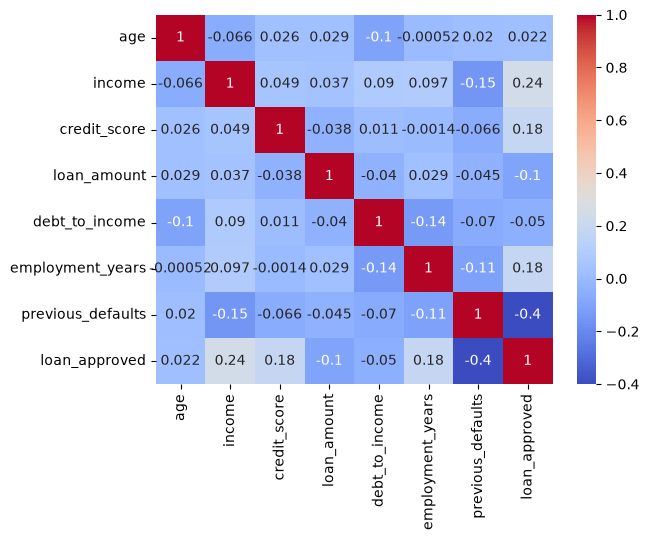

In [5]:
sns.heatmap(
    df[['age', 'income', 'credit_score', 'loan_amount',
        'debt_to_income', 'employment_years',
        'previous_defaults', 'loan_approved']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [6]:
df = df.drop(columns=['age', 'debt_to_income'])

In [7]:
df

,income,credit_score,loan_amount,employment_years,previous_defaults,loan_approved
0,30539,651,12941,1,0,1
1,132941,677,19388,24,0,1
2,78351,662,10569,25,0,1
3,86267,532,9300,8,0,1
4,148133,678,44037,16,0,1
...,...,...,...,...,...,...
295,74115,829,12783,29,0,1
296,116007,772,49241,13,2,1
297,113223,839,22368,6,0,1
298,85890,568,20328,16,1,1


In [8]:
X = df.drop(['loan_approved'], axis='columns')
y = df['loan_approved']

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:3]

array([[-1.61573007, -0.24304698, -0.95675133, -1.54230228, -0.46061452],
       [ 1.23209804,  0.02216937, -0.46608074,  1.02882257, -0.46061452],
       [-0.28606505, -0.13084006, -1.13728036,  1.1406106 , -0.46061452]])

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    stratify=y,
    random_state=10
)

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

scores = cross_val_score(DecisionTreeClassifier(), X, y, cv=5)
scores

array([0.95      , 0.93333333, 0.96666667, 0.93333333, 0.91666667])

In [12]:
scores.mean()

np.float64(0.9400000000000001)

In [13]:
from sklearn.ensemble import BaggingClassifier

Bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    oob_score=True,
    random_state=0
)
Bag_model.fit(X_train, y_train)
Bag_model.oob_score_

0.9555555555555556

In [14]:
Bag_model.score(X_test,y_test)

0.96

In [15]:
Bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    oob_score=True,
    random_state=0
)

scores = cross_val_score(Bag_model, X, y, cv=5)
scores.mean()

np.float64(0.9666666666666666)

In [16]:
from sklearn.ensemble import RandomForestClassifier

scores = cross_val_score(RandomForestClassifier(),X,y,cv=5)
scores.mean()

np.float64(0.96)

In [18]:
#bagging is quite effficient, but the end of these lessons has taught me to focus on parameter selection and data cleaning 
